In [0]:
# Dataframe 
import pandas as pd
import numpy as np

# EDA
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_ccf
import matplotlib.pyplot as plt

# Feature Engineering
from itertools import groupby
from sklearn.preprocessing import LabelEncoder

# ML model building & evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from sklearn.inspection import permutation_importance
import shap

# Hyperparameter tuning
import optuna
from optuna.pruners import MedianPruner

# Mlflow documentation
import mlflow.xgboost
from pyspark.sql import SparkSession

In [0]:
# Load from Delta table and convert to Pandas
df_quarterly = spark.table("workspace.canada_labour_market.mart_quarterly_sector_metrics").toPandas()


# Quarterly


## EDA

In [0]:
df_quarterly.dtypes
df_quarterly['date_parsed'] = pd.to_datetime(df_quarterly['date_parsed'])

In [0]:
df_quarterly

,date_parsed,geo,year,naics,job_vacancies,job_vacancy_rate,avg_offered_hourly_wage,payroll_employees,vacancies_per_1000,prev_year_vacancies_per_1000,prev_year_vacancy_rate,prev_year_wage,vacancy_rate_yoy_change_pct,wage_yoy_change_pct,demand_rank,p75_vacancy_rate,p50_vacancy_rate,pct_quarters_above_threshold_2yr,lmia_high_wage_threshold,foreign_accessibility_tier
0,2015-01-01,Alberta,2015,Accommodation and food services [72],NaN,NaN,12.55,171575.0,NaN,NaN,NaN,NaN,NaN,NaN,5,3.500,2.50,100.0,36.0,Low
1,2015-04-01,Alberta,2015,Accommodation and food services [72],16235.0,8.7,12.60,170980.0,94.952626,NaN,NaN,NaN,NaN,NaN,1,3.500,2.50,100.0,36.0,"High Demand and Sustained, Below Wage Threshold"
2,2015-07-01,Alberta,2015,Accommodation and food services [72],14420.0,7.7,12.70,173275.0,83.220315,NaN,NaN,NaN,NaN,NaN,1,3.500,2.50,100.0,36.0,"High Demand and Sustained, Below Wage Threshold"
3,2015-10-01,Alberta,2015,Accommodation and food services [72],11660.0,6.3,12.85,172455.0,67.611841,NaN,NaN,NaN,NaN,NaN,1,3.500,2.50,100.0,36.0,"High Demand and Sustained, Below Wage Threshold"
4,2016-01-01,Alberta,2016,Accommodation and food services [72],9000.0,5.1,13.00,166955.0,53.906741,NaN,NaN,12.55,NaN,3.59,1,2.500,1.80,100.0,36.0,"High Demand and Sustained, Below Wage Threshold"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12049,2024-07-01,Yukon,2024,Wholesale trade [41],NaN,5.7,29.60,405.0,NaN,NaN,5.6,28.45,NaN,4.04,3,6.075,5.10,16.7,44.4,"Above Average Demand, Below Wage Threshold"
12050,2024-10-01,Yukon,2024,Wholesale trade [41],NaN,NaN,31.25,NaN,NaN,70.0,6.6,35.25,NaN,-11.35,5,6.075,5.10,16.7,44.4,Low
12051,2025-01-01,Yukon,2025,Wholesale trade [41],NaN,2.0,36.75,460.0,NaN,NaN,3.7,27.60,NaN,33.15,6,4.875,3.55,16.7,44.4,Low
12052,2025-04-01,Yukon,2025,Wholesale trade [41],NaN,6.0,31.55,470.0,NaN,NaN,5.1,26.15,NaN,20.65,2,4.875,3.55,16.7,44.4,"Above Average Demand, Below Wage Threshold"


Canada's vacancies_per_1000 seasonality, residuals, and autocorrelation plots


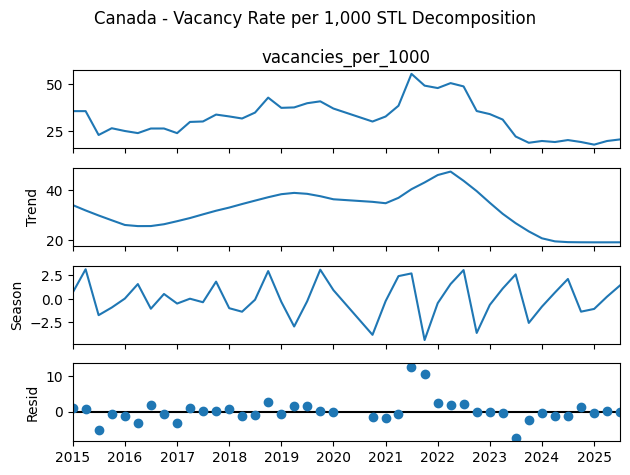

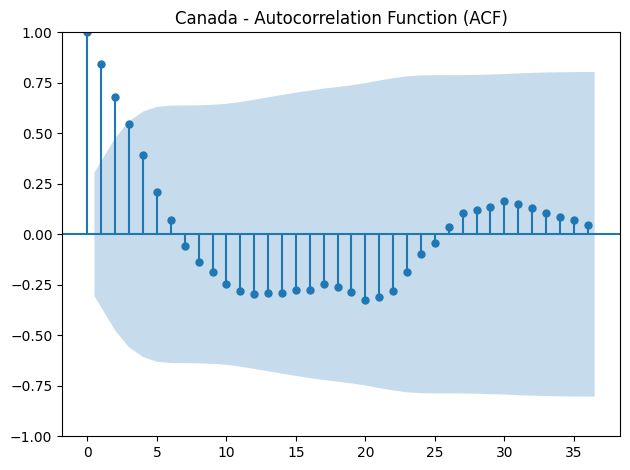

In [0]:
def prepare_vis_series(df_geo):
    series = (
        df_geo
        .set_index('date_parsed')['vacancies_per_1000']
        .interpolate(method='linear')
        .ffill()
        .bfill()
    )
    return series


df_canada_quarterly = df_quarterly[(df_quarterly['geo'] == "Canada") & (df_quarterly['naics'] == "Information and cultural industries [51]")].sort_values('date_parsed')
vis_series = prepare_vis_series(df_canada_quarterly)
    
print(f"Canada's vacancies_per_1000 seasonality, residuals, and autocorrelation plots")
stl_vacancies = STL(vis_series, period=4, robust=True).fit()
fig = stl_vacancies.plot()
fig.suptitle(f"Canada - Vacancy Rate per 1,000 STL Decomposition")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
plot_acf(vis_series, lags=36, ax=ax)
ax.set_title(f"Canada - Autocorrelation Function (ACF)")
plt.tight_layout()
plt.show()

Canada's avg_offered_hourly_wage seasonality, residuals, and autocorrelation plots


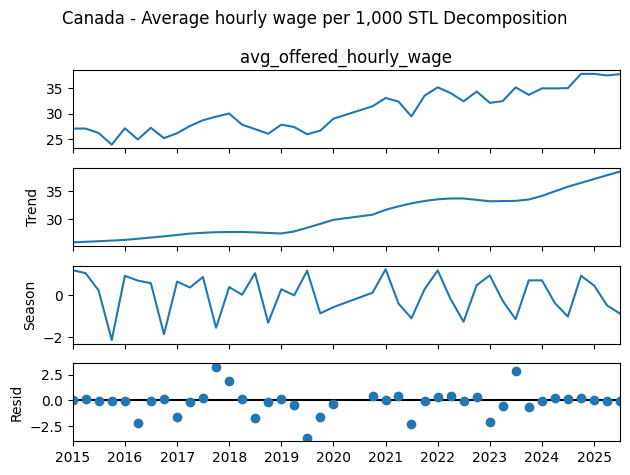

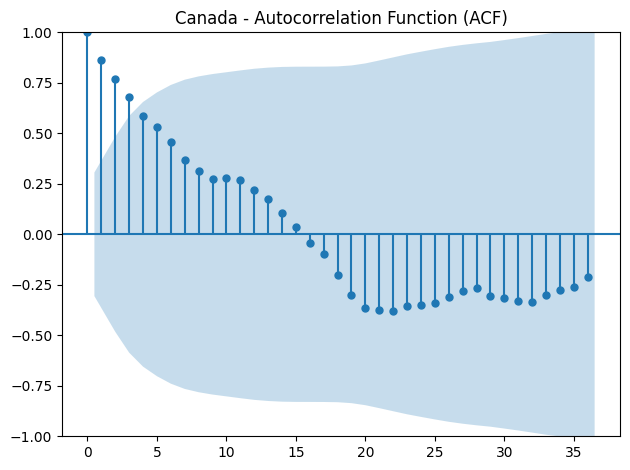

In [0]:
def prepare_vis_series(df_geo):
    series = (
        df_geo
        .set_index('date_parsed')['avg_offered_hourly_wage']
        .interpolate(method='linear')
        .ffill()
        .bfill()
    )
    return series


df_canada_quarterly = df_quarterly[(df_quarterly['geo'] == "Canada") & (df_quarterly['naics'] == "Information and cultural industries [51]")].sort_values('date_parsed')
vis_series = prepare_vis_series(df_canada_quarterly)
    
print(f"Canada's avg_offered_hourly_wage seasonality, residuals, and autocorrelation plots")
stl_vacancies = STL(vis_series, period=4, robust=True).fit()
fig = stl_vacancies.plot()
fig.suptitle(f"Canada - Average hourly wage per 1,000 STL Decomposition")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
plot_acf(vis_series, lags=36, ax=ax)
ax.set_title(f"Canada - Autocorrelation Function (ACF)")
plt.tight_layout()
plt.show()

In [0]:
# Check missing values per geo and naics
# avg_offered_hourly_wage
pct_more_10_vacancies = []
pct_less_10_vacancies = []
geo_less_10_vacancies = []

for geo in df_quarterly['geo'].unique():
    df_geo = df_quarterly[df_quarterly['geo'] == geo]
    missing = df_geo['vacancies_per_1000'].isna().sum()
    total = len(df_geo)
    pct = missing/total*100
    total_periods_vacancies = len(df_geo['date_parsed'].unique())

    naics_list = []
    if pct > 10:
        pct_more_10_vacancies.append(f"{geo} - {missing} missing ({pct:.1f}%)")
        for naics in df_geo['naics'].unique():  # checks which NAICS sector has the most missing values in that geo
            missing_in_naics = df_geo[df_geo['naics'] == naics]['vacancies_per_1000'].isna().sum()
            naics_list.append((naics, missing_in_naics))

        top_3_missing_naics = sorted(naics_list, key=lambda x: x[1], reverse=True)[:5]
           
        for naics, count in top_3_missing_naics:
            pct_more_10_vacancies.append(f"       {naics}: {count} missing, {(count/total_periods_vacancies)*100:.1f}% of this naics data is missing")
    else:
        pct_less_10_vacancies.append(f"{geo} - {missing} missing ({pct:.1f}%) ")
        geo_less_10_vacancies.append(geo)


print("Over 10% missing:")
for i in pct_more_10_vacancies:
    print(i)

print("\nUnder 10% missing:")
for i in pct_less_10_vacancies:
    print(i)

Over 10% missing:
Manitoba - 127 missing (14.8%)
       Utilities [22]: 40 missing, 97.6% of this naics data is missing
       Mining, quarrying, and oil and gas extraction [21]: 38 missing, 92.7% of this naics data is missing
       Management of companies and enterprises [55]: 21 missing, 51.2% of this naics data is missing
       Real estate and rental and leasing [53]: 12 missing, 29.3% of this naics data is missing
       Agriculture, forestry, fishing and hunting [11]: 2 missing, 4.9% of this naics data is missing
New Brunswick - 160 missing (18.6%)
       Mining, quarrying, and oil and gas extraction [21]: 36 missing, 87.8% of this naics data is missing
       Utilities [22]: 32 missing, 78.0% of this naics data is missing
       Management of companies and enterprises [55]: 30 missing, 73.2% of this naics data is missing
       Real estate and rental and leasing [53]: 20 missing, 48.8% of this naics data is missing
       Information and cultural industries [51]: 10 missing, 24

In [0]:
# Check missing values per geo and naics
# avg_offered_hourly_wage
pct_more_10_wage = []
pct_less_10_wage = []
geo_less_10_wage = []

for geo in df_quarterly['geo'].unique():
    df_geo = df_quarterly[df_quarterly['geo'] == geo]
    missing = df_geo['avg_offered_hourly_wage'].isna().sum()
    total = len(df_geo)
    pct = missing/total*100
    total_periods_wage = len(df_geo['date_parsed'].unique())

    naics_list = []
    if pct > 10:
        pct_more_10_wage.append(f"{geo} - {missing} missing ({pct:.1f}%)")
        for naics in df_geo['naics'].unique():  # checks which NAICS sector has the most missing values in that geo
            missing_in_naics = df_geo[df_geo['naics'] == naics]['avg_offered_hourly_wage'].isna().sum()
            naics_list.append((naics, missing_in_naics))

        top_3_missing_naics = sorted(naics_list, key=lambda x: x[1], reverse=True)[:5]
           
        for naics, count in top_3_missing_naics:
            pct_more_10_wage.append(f"       {naics}: {count} missing, {(count/total_periods_wage)*100:.1f}% of this naics data is missing")
    else:
        pct_less_10_wage.append(f"{geo} - {missing} missing ({pct:.1f}%) ")
        geo_less_10_wage.append(geo)


print("Over 10% missing:")
for i in pct_more_10_wage:
    print(i)

print("\nUnder 10% missing:")
for i in pct_less_10_wage:
    print(i)

Over 10% missing:
New Brunswick - 90 missing (10.5%)
       Utilities [22]: 26 missing, 63.4% of this naics data is missing
       Mining, quarrying, and oil and gas extraction [21]: 25 missing, 61.0% of this naics data is missing
       Management of companies and enterprises [55]: 21 missing, 51.2% of this naics data is missing
       Arts, entertainment and recreation [71]: 3 missing, 7.3% of this naics data is missing
       Public administration [91]: 3 missing, 7.3% of this naics data is missing
Newfoundland and Labrador - 111 missing (12.9%)
       Management of companies and enterprises [55]: 28 missing, 68.3% of this naics data is missing
       Real estate and rental and leasing [53]: 15 missing, 36.6% of this naics data is missing
       Agriculture, forestry, fishing and hunting [11]: 13 missing, 31.7% of this naics data is missing
       Utilities [22]: 12 missing, 29.3% of this naics data is missing
       Arts, entertainment and recreation [71]: 10 missing, 24.4% of this

In [0]:
# Checking how many missing quarters per year for geo with more than 10% missing data

# Vacancies per 1000
naics_summary_vacancies = []
total_periods = len(df_geo['date_parsed'].unique())

for geo in df_quarterly['geo'].unique():
    df_geo = df_quarterly[df_quarterly['geo'] == geo]
    missing_vacancies = df_geo['vacancies_per_1000'].isna().sum()
    total = len(df_geo)
    pct = missing_vacancies/total*100

    if pct > 10:
        naics_summary_vacancies.append(f"\n{geo}")
        pct_more_10_vacancies.append(f"{geo} - {missing_vacancies} missing ({pct:.1f}%)")
        for naics in df_geo['naics'].unique():  # checks which NAICS sector has the most missing values in that geo
            df_naics = df_geo[df_geo['naics'] == naics]
            missing_in_naics_vacancies = df_naics['vacancies_per_1000'].isna().sum()

            if missing_in_naics_vacancies >= total_periods*0.3:
                naics_summary_vacancies.append(f"{naics}: {missing_in_naics_vacancies} missing {missing_in_naics_vacancies/total_periods*100:.1f}%")
                if missing_in_naics_vacancies <= total_periods * 0.5:
                    for year in df_naics['year'].unique():
                        missing_year_vacancies = df_naics[df_naics['year'] == year]['vacancies_per_1000'].isna().sum()
                        naics_summary_vacancies.append(f"{year}: {missing_year_vacancies} missing quarters")

for i in naics_summary_vacancies:
    print(i)



Manitoba
Management of companies and enterprises [55]: 21 missing 51.2%
Mining, quarrying, and oil and gas extraction [21]: 38 missing 92.7%
Utilities [22]: 40 missing 97.6%

New Brunswick
Management of companies and enterprises [55]: 30 missing 73.2%
Mining, quarrying, and oil and gas extraction [21]: 36 missing 87.8%
Real estate and rental and leasing [53]: 20 missing 48.8%
2015: 3 missing quarters
2016: 4 missing quarters
2017: 2 missing quarters
2018: 2 missing quarters
2019: 4 missing quarters
2020: 1 missing quarters
2021: 0 missing quarters
2022: 0 missing quarters
2023: 0 missing quarters
2024: 2 missing quarters
2025: 2 missing quarters
Utilities [22]: 32 missing 78.0%

Newfoundland and Labrador
Agriculture, forestry, fishing and hunting [11]: 30 missing 73.2%
Arts, entertainment and recreation [71]: 24 missing 58.5%
Construction [23]: 15 missing 36.6%
2015: 1 missing quarters
2016: 2 missing quarters
2017: 0 missing quarters
2018: 3 missing quarters
2019: 2 missing quarters


In [0]:
# Average hourly wage
naics_summary_wage = []
total_periods = len(df_geo['date_parsed'].unique())

for geo in df_quarterly['geo'].unique():
    df_geo = df_quarterly[df_quarterly['geo'] == geo]
    missing_wage = df_geo['avg_offered_hourly_wage'].isna().sum()
    total = len(df_geo)
    pct = missing_wage/total*100

    if pct > 10:
        naics_summary_wage.append(f"\n{geo}")
        pct_more_10_wage.append(f"{geo} - {missing_wage} missing ({pct:.1f}%)")
        for naics in df_geo['naics'].unique():  # checks which NAICS sector has the most missing values in that geo
            df_naics = df_geo[df_geo['naics'] == naics]
            missing_in_naics_wage = df_naics['avg_offered_hourly_wage'].isna().sum()

            if missing_in_naics_wage >= total_periods*0.3:
                naics_summary_wage.append(f"{naics}: {missing_in_naics_wage} missing {missing_in_naics_wage/total_periods*100:.1f}%")
                if missing_in_naics_wage <= total_periods * 0.5:
                    for year in df_naics['year'].unique():
                        missing_year_wage = df_naics[df_naics['year'] == year]['avg_offered_hourly_wage'].isna().sum()
                        if missing_year_wage >= 1:
                            naics_summary_wage.append(f"{year}: {missing_year_wage} missing quarters")

for i in naics_summary_wage:
    print(i)


New Brunswick
Management of companies and enterprises [55]: 21 missing 51.2%
Mining, quarrying, and oil and gas extraction [21]: 25 missing 61.0%
Utilities [22]: 26 missing 63.4%

Newfoundland and Labrador
Agriculture, forestry, fishing and hunting [11]: 13 missing 31.7%
2015: 2 missing quarters
2016: 3 missing quarters
2017: 2 missing quarters
2018: 3 missing quarters
2019: 2 missing quarters
2022: 1 missing quarters
Management of companies and enterprises [55]: 28 missing 68.3%
Real estate and rental and leasing [53]: 15 missing 36.6%
2016: 4 missing quarters
2017: 3 missing quarters
2018: 2 missing quarters
2019: 3 missing quarters
2020: 1 missing quarters
2021: 2 missing quarters

Northwest Territories
Administrative and support, waste management and remediation services [56]: 27 missing 65.9%
Agriculture, forestry, fishing and hunting [11]: 41 missing 100.0%
Arts, entertainment and recreation [71]: 41 missing 100.0%
Educational services [61]: 19 missing 46.3%
2015: 4 missing quar

In [0]:
anomalies_vacancies_results = []
anomalies_wage_results = []

for geo in df_quarterly['geo'].unique():
    df_geo = df_quarterly[df_quarterly["geo"] == geo]
    for naics in df_geo['naics'].unique():
        df_naics = df_geo[df_geo['naics'] == naics]

        if len(df_naics) >= 12:
            mean_vacancies = df_naics['vacancies_per_1000'].mean()
            std_vacancies = df_naics['vacancies_per_1000'].std()
            if pd.notna(std_vacancies) and std_vacancies > 0:
                mask = np.abs(df_naics['vacancies_per_1000'] - mean_vacancies) > 3.5 * std_vacancies
                if mask.any():
                    years = sorted(df_naics.loc[mask, 'date_parsed'].dt.year.unique().tolist())
                    anomalies_vacancies_results.append(f"Vacancy Anomalies in {geo} {naics} -> {years}")

            mean_wage = df_naics['avg_offered_hourly_wage'].mean()
            std_wage = df_naics['avg_offered_hourly_wage'].std()
            if pd.notna(std_wage) and std_wage > 0:
                mask = np.abs(df_naics['avg_offered_hourly_wage'] - mean_wage) > 3.5 * std_wage
                if mask.any():
                    years = sorted(df_naics.loc[mask, 'date_parsed'].dt.year.unique().tolist())
                    anomalies_wage_results.append(f"Wage Anomalies in {geo} {naics} -> {years}")

if not anomalies_vacancies_results:
    anomalies_vacancies_results.append("No anomalies found in vacancies per 1000")
if not anomalies_wage_results:
    anomalies_wage_results.append("No anomalies found in average wage")

print("Vacancy anomalies:")
print("\n".join(anomalies_vacancies_results))
print("\nWage anomalies:")
print("\n".join(anomalies_wage_results))

Vacancy anomalies:
Vacancy Anomalies in Prince Edward Island Educational services [61] -> [2023]
Vacancy Anomalies in Yukon Retail trade [44-45] -> [2022]

Wage anomalies:
Wage Anomalies in British Columbia Finance and insurance [52] -> [2022]
Wage Anomalies in British Columbia Mining, quarrying, and oil and gas extraction [21] -> [2025]
Wage Anomalies in New Brunswick Information and cultural industries [51] -> [2015]
Wage Anomalies in Prince Edward Island Manufacturing [31-33] -> [2025]
Wage Anomalies in Saskatchewan Health care and social assistance [62] -> [2018]
Wage Anomalies in Saskatchewan Real estate and rental and leasing [53] -> [2023]


In [0]:
anomalies_wage_results = []

for geo in df_quarterly['geo'].unique():
    df_geo = df_quarterly[df_quarterly["geo"] == geo]
    for naics in df_geo['naics'].unique():
        df_naics = df_geo[df_geo['naics'] == naics]
        if len(df_naics) >= 12:
            mean_wage = df_naics['avg_offered_hourly_wage'].mean()
            std_wage = df_naics['avg_offered_hourly_wage'].std()
            if pd.notna(std_wage) and std_wage > 0:
                if pd.notna(std_wage) and std_wage > 0:
                    mask = np.abs(df_naics['avg_offered_hourly_wage'] - mean_wage) > 3.5 * std_wage
                    if mask.any():
                        print(df_naics.loc[mask, ['date_parsed', 'geo', 'naics', 'avg_offered_hourly_wage']])

     date_parsed  ... avg_offered_hourly_wage
1136  2022-10-01  ...                    48.0

[1 rows x 4 columns]
     date_parsed  ... avg_offered_hourly_wage
1350  2025-01-01  ...                   51.35

[1 rows x 4 columns]
     date_parsed  ... avg_offered_hourly_wage
3773  2015-04-01  ...                   45.55

[1 rows x 4 columns]
     date_parsed  ... avg_offered_hourly_wage
9058  2025-01-01  ...                   27.25

[1 rows x 4 columns]
      date_parsed  ... avg_offered_hourly_wage
10631  2018-01-01  ...                   34.25

[1 rows x 4 columns]
      date_parsed  ... avg_offered_hourly_wage
10977  2023-01-01  ...                   37.25

[1 rows x 4 columns]


In [0]:
df_quarterly[df_quarterly['geo'] == 'New Brunswick'][df_quarterly['naics'] == 'Information and cultural industries [51]']

/home/spark-5af89514-6a8e-451f-8dde-49/.ipykernel/3232/command-8765123313364685-661481214:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_quarterly[df_quarterly['geo'] == 'New Brunswick'][df_quarterly['naics'] == 'Information and cultural industries [51]']


,date_parsed,geo,year,naics,job_vacancies,job_vacancy_rate,avg_offered_hourly_wage,payroll_employees,vacancies_per_1000,prev_year_vacancies_per_1000,prev_year_vacancy_rate,prev_year_wage,vacancy_rate_yoy_change_pct,wage_yoy_change_pct,demand_rank,p75_vacancy_rate,p50_vacancy_rate,pct_quarters_above_threshold_2yr,lmia_high_wage_threshold,foreign_accessibility_tier
3772,2015-01-01,New Brunswick,2015,Information and cultural industries [51],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,3.100,2.30,0.0,30.0,Insufficient Data
3773,2015-04-01,New Brunswick,2015,Information and cultural industries [51],NaN,NaN,45.55,6795.0,NaN,NaN,NaN,NaN,NaN,NaN,16,3.100,2.30,0.0,30.0,"Wage Eligible, No Vacancy Data"
3774,2015-07-01,New Brunswick,2015,Information and cultural industries [51],275.0,3.5,34.40,7540.0,36.472149,NaN,NaN,NaN,NaN,NaN,3,3.100,2.30,0.0,30.0,"Wage Eligible, High Demand"
3775,2015-10-01,New Brunswick,2015,Information and cultural industries [51],90.0,1.2,22.35,7760.0,11.597938,NaN,NaN,NaN,NaN,NaN,14,3.100,2.30,0.0,30.0,Low
3776,2016-01-01,New Brunswick,2016,Information and cultural industries [51],275.0,3.7,15.90,7055.0,38.979447,NaN,NaN,NaN,NaN,NaN,1,2.700,2.10,0.0,30.0,"Above Average Demand, Below Wage Threshold"
3777,2016-04-01,New Brunswick,2016,Information and cultural industries [51],205.0,2.9,15.50,6825.0,30.036630,NaN,NaN,45.55,NaN,-65.97,6,2.700,2.10,0.0,30.0,"Above Average Demand, Below Wage Threshold"
3778,2016-07-01,New Brunswick,2016,Information and cultural industries [51],165.0,2.5,20.30,6295.0,26.211279,36.472149,3.5,34.40,-28.13,-40.99,6,2.700,2.10,0.0,30.0,"Above Average Demand, Below Wage Threshold"
3779,2016-10-01,New Brunswick,2016,Information and cultural industries [51],170.0,2.7,17.00,6210.0,27.375201,11.597938,1.2,22.35,136.04,-23.94,5,2.700,2.10,0.0,30.0,"Above Average Demand, Below Wage Threshold"
3780,2017-01-01,New Brunswick,2017,Information and cultural industries [51],175.0,2.6,23.00,6625.0,26.415094,38.979447,3.7,15.90,-32.23,44.65,4,3.000,2.40,0.0,30.0,"Above Average Demand, Below Wage Threshold"
3781,2017-04-01,New Brunswick,2017,Information and cultural industries [51],140.0,2.1,20.35,6465.0,21.655066,30.036630,2.9,15.50,-27.90,31.29,15,3.000,2.40,0.0,30.0,Low


In [0]:
df_quarterly.isna().sum()

date_parsed                            0
geo                                    0
year                                   0
naics                                  0
job_vacancies                       2854
job_vacancy_rate                    2762
avg_offered_hourly_wage             2227
payroll_employees                   1507
vacancies_per_1000                  3235
prev_year_vacancies_per_1000        4096
prev_year_vacancy_rate              3678
prev_year_wage                      3233
vacancy_rate_yoy_change_pct         4706
wage_yoy_change_pct                 3663
demand_rank                            0
p75_vacancy_rate                       0
p50_vacancy_rate                       0
pct_quarters_above_threshold_2yr       0
lmia_high_wage_threshold               0
foreign_accessibility_tier             0
dtype: int64

In [0]:
expected_quarter = pd.date_range(
    start='2015-01-01',
    end=df_quarterly['date_parsed'].max(),
    freq='QS'
)
actual_quarter = set(df_quarterly['date_parsed'].unique())
missing_quarter = sorted(set(expected_quarter) - actual_quarter)
        
if missing_quarter:
    print(f"There are {len(missing_quarter)} missing quarters in df_quarterly:")
    for d in missing_quarter:
        print(f"    {d.strftime('%Y-%m')}")

else:
    print("All quarters present")


There are 2 missing quarters in df_quarterly:
    2020-04
    2020-07


In [0]:
# Create missing rows for each geo
missing_quarterly_rows = []

for geo in df_quarterly['geo'].unique():
    for quarters in missing_quarter:
        for naics in df_quarterly['naics'].unique():
            missing_quarterly_rows.append({
                'date_parsed': quarters,
                'geo': geo,
                'year': quarters.year,
                'naics' : naics,
                # all other columns are NaN as they genuinely have no data
            })

df_quarterly_missing = pd.DataFrame(missing_quarterly_rows)

# Combine with existing data and sort
df_quarterly_complete = (
    pd.concat([df_quarterly, df_quarterly_missing], ignore_index=True)
    .sort_values(['geo', 'date_parsed', 'naics'])
    .reset_index(drop=True)
)

print(f"Original rows: {len(df_quarterly)}")
print(f"Added rows: {len(df_quarterly_missing)}\n")

if len(df_quarterly_missing) == len(df_quarterly['geo'].unique()) * len(df_quarterly['naics'].unique()) * len(missing_quarter):
    print("Correct amount of rows predicted")
else:
    print("Too many or too little number of rows")

print(f"Complete rows: {len(df_quarterly_complete)}")

Original rows: 12054
Added rows: 588

Correct amount of rows predicted
Complete rows: 12642


## Feature Engineering

In [0]:
exclude_geos = ['Northwest Territories','Yukon','Nunavut'] # dropped due to high missing data %, over 70%
df_quarterly_no_territories = df_quarterly_complete[~df_quarterly_complete['geo'].isin(exclude_geos)].copy()

threshold_pct = 0.5
threshold_consecutive = 4

keys_to_drop = set()

for geo in df_quarterly_no_territories['geo'].unique():
    for naics in df_quarterly_no_territories['naics'].unique():
        df_series = df_quarterly_no_territories[
            (df_quarterly_no_territories['geo'] == geo) &
            (df_quarterly_no_territories['naics'] == naics)
        ].sort_values('date_parsed')  # ensure time order

        null_mask = df_series['vacancies_per_1000'].isna()

        null_pct = null_mask.mean()
        max_consecutive = max(
            (sum(1 for _ in group) for is_null, group in groupby(null_mask) if is_null),
            default=0
        )

        if null_pct > threshold_pct or max_consecutive >= threshold_consecutive:
            keys_to_drop.add((geo, naics))

df_quarterly_clean = df_quarterly_no_territories[
    ~df_quarterly_no_territories.apply(
        lambda row: (row['geo'], row['naics']) in keys_to_drop, axis=1
    )
].copy()

In [0]:
df_quarterly_interpolated = df_quarterly_clean.copy()
df_quarterly_interpolated['vacancies_per_1000'] = df_quarterly_interpolated.groupby(['geo', 'naics'])['vacancies_per_1000'].transform(
    lambda x: 
        x.interpolate(method='linear', limit=3)
        .ffill()
)

df_quarterly_interpolated['avg_offered_hourly_wage'] = df_quarterly_interpolated.groupby(['geo', 'naics'])['avg_offered_hourly_wage'].transform(
    lambda x: 
        x.interpolate(method='linear', limit=3)
        .ffill()
)



In [0]:
df_quarterly_interpolated.isna().sum() # The rest of Na in avg_offered_hourly_wage and vacancies_per_1000 can't be filled as they appear in the beginning of the time series, so only a bfill can fill them, but that would cause leakage

date_parsed                            0
geo                                    0
year                                   0
naics                                  0
job_vacancies                        668
job_vacancy_rate                     657
avg_offered_hourly_wage               74
payroll_employees                    436
vacancies_per_1000                   152
prev_year_vacancies_per_1000        1417
prev_year_vacancy_rate              1408
prev_year_wage                      1265
vacancy_rate_yoy_change_pct         1524
wage_yoy_change_pct                 1299
demand_rank                          382
p75_vacancy_rate                     382
p50_vacancy_rate                     382
pct_quarters_above_threshold_2yr     382
lmia_high_wage_threshold             382
foreign_accessibility_tier           382
dtype: int64

In [0]:
df_quarterly_interpolated[df_quarterly_interpolated['avg_offered_hourly_wage'].isna()]['date_parsed'].unique()

<DatetimeArray>
['2015-01-01 00:00:00', '2015-04-01 00:00:00', '2015-07-01 00:00:00']
Length: 3, dtype: datetime64[ns]

In [0]:
def create_features(df, target_col):
    # Lags
    for lag in [1, 2, 3, 4, 5, 6]:
        df[f"{target_col}_lag{lag}"] = df.groupby(['geo','naics'])[target_col].shift(lag)
    
    # Rolling averages
    df[f"{target_col}_roll2"] = df.groupby(['geo','naics'])[target_col].transform(lambda x: x.shift(1).rolling(2).mean())
    df[f"{target_col}_roll3"] = df.groupby(['geo','naics'])[target_col].transform(lambda x: x.shift(1).rolling(3).mean())
    df[f"{target_col}_roll6"] = df.groupby(['geo','naics'])[target_col].transform(lambda x: x.shift(1).rolling(6).mean())
    
    return df

def add_shared_features(df):
    df['quarter'] = df['date_parsed'].dt.month
    df['quarter_sin'] = np.sin(2 * np.pi * df['quarter'] / 4)
    df['quarter_cos'] = np.cos(2 * np.pi * df['quarter'] / 4)
    df['is_covid'] = df['date_parsed'].between('2020-04-01', '2021-07-01').astype(int)
    df['is_post_covid_boom'] = df['date_parsed'].between('2021-10-01', '2023-01-01').astype(int)

    le = LabelEncoder()
    df['geo_encoded'] = le.fit_transform(df['geo'])
    df['naics_encoded'] = le.fit_transform(df['naics'])
    
    return df

df_quarterly_features = df_quarterly_interpolated.copy()
df_quarterly_features = create_features(df_quarterly_features, 'vacancies_per_1000')
df_quarterly_features = create_features(df_quarterly_features, 'avg_offered_hourly_wage')
df_quarterly_features = add_shared_features(df_quarterly_features)

In [0]:
df_quarterly_features['date_parsed'].unique()

<DatetimeArray>
['2015-01-01 00:00:00', '2015-04-01 00:00:00', '2015-07-01 00:00:00',
 '2015-10-01 00:00:00', '2016-01-01 00:00:00', '2016-04-01 00:00:00',
 '2016-07-01 00:00:00', '2016-10-01 00:00:00', '2017-01-01 00:00:00',
 '2017-04-01 00:00:00', '2017-07-01 00:00:00', '2017-10-01 00:00:00',
 '2018-01-01 00:00:00', '2018-04-01 00:00:00', '2018-07-01 00:00:00',
 '2018-10-01 00:00:00', '2019-01-01 00:00:00', '2019-04-01 00:00:00',
 '2019-07-01 00:00:00', '2019-10-01 00:00:00', '2020-01-01 00:00:00',
 '2020-04-01 00:00:00', '2020-07-01 00:00:00', '2020-10-01 00:00:00',
 '2021-01-01 00:00:00', '2021-04-01 00:00:00', '2021-07-01 00:00:00',
 '2021-10-01 00:00:00', '2022-01-01 00:00:00', '2022-04-01 00:00:00',
 '2022-07-01 00:00:00', '2022-10-01 00:00:00', '2023-01-01 00:00:00',
 '2023-04-01 00:00:00', '2023-07-01 00:00:00', '2023-10-01 00:00:00',
 '2024-01-01 00:00:00', '2024-04-01 00:00:00', '2024-07-01 00:00:00',
 '2024-10-01 00:00:00', '2025-01-01 00:00:00', '2025-04-01 00:00:00',
 '20


## Quarterly Model Training


### Data Preparation

In [0]:
feature_cols = (
    [f"vacancies_per_1000_lag{i}" for i in [1, 2, 3, 4, 5, 6]] +
    [f"avg_offered_hourly_wage_lag{i}" for i in [1, 2, 3, 4, 5, 6]] +
    [f"vacancies_per_1000_roll{w}" for w in [2, 3, 6]] +
    [f"avg_offered_hourly_wage_roll{w}" for w in [2, 3, 6]] +
    ['quarter', 'quarter_sin', 'quarter_cos',
     'is_covid', 'is_post_covid_boom',
     'geo_encoded', 'naics_encoded']
)

remove_cols_vacancies = [
    'avg_offered_hourly_wage_lag2',
    'vacancies_per_1000_lag2',
    'avg_offered_hourly_wage_lag3',
    'geo_encoded',
    'avg_offered_hourly_wage_roll3',
    'avg_offered_hourly_wage_lag1',
    'quarter',
    'avg_offered_hourly_wage_roll6',
    'vacancies_per_1000_roll6',
    # 'vacancies_per_1000_roll2',
    'avg_offered_hourly_wage_lag6',
    # 'vacancies_per_1000_lag3',
    'avg_offered_hourly_wage_roll2',
    'quarter_sin',
    # 'avg_offered_hourly_wage_lag4',
    'avg_offered_hourly_wage_lag5',
    'vacancies_per_1000_lag1',
]


# Vacancies per 1000
vacancies_feature_cols = [col for col in feature_cols if col not in remove_cols_vacancies]
cutoff_partition = pd.Timestamp('2023-07-01')

valid_mask_vacancies = df_quarterly_features['vacancies_per_1000'].notna()
train_mask_vacancies = df_quarterly_features['date_parsed'] < cutoff_partition
test_mask_vacancies = ~train_mask_vacancies

quarterly_x_vacancies_train = df_quarterly_features[vacancies_feature_cols][train_mask_vacancies & valid_mask_vacancies].reset_index(drop=True)
quarterly_y_vacancies_train = df_quarterly_features['vacancies_per_1000'][train_mask_vacancies & valid_mask_vacancies].reset_index(drop=True)

quarterly_x_vacancies_test = df_quarterly_features[vacancies_feature_cols][test_mask_vacancies & valid_mask_vacancies].reset_index(drop=True)
quarterly_y_vacancies_test = df_quarterly_features['vacancies_per_1000'][test_mask_vacancies & valid_mask_vacancies].reset_index(drop=True)

quarterly_x_vacancies_final = df_quarterly_features[vacancies_feature_cols][valid_mask_vacancies].reset_index(drop=True)
quarterly_y_vacancies_final = df_quarterly_features['vacancies_per_1000'][valid_mask_vacancies].reset_index(drop=True)

# Wage
remove_cols_wage = [
    'avg_offered_hourly_wage_lag5',
    'is_covid',
    'avg_offered_hourly_wage_roll2',
    'vacancies_per_1000_roll6',
    'vacancies_per_1000_lag4',
    'avg_offered_hourly_wage_roll6',
    'avg_offered_hourly_wage_roll3',
    'vacancies_per_1000_lag1',
    'vacancies_per_1000_lag3',
    'vacancies_per_1000_lag6',
    'vacancies_per_1000_lag2',
    'vacancies_per_1000_roll2', 
    'vacancies_per_1000_roll3',   
    'vacancies_per_1000_lag5',
    'is_post_covid_boom',
    'quarter',
    'quarter_sin',
    'geo_encoded',
    'naics_encoded'
]

wage_feature_cols = [col for col in feature_cols if col not in remove_cols_wage]

valid_mask_wage = df_quarterly_features['avg_offered_hourly_wage'].notna()
train_mask_wage = df_quarterly_features['date_parsed'] < cutoff_partition
test_mask_wage = ~train_mask_wage

quarterly_x_wage_train = df_quarterly_features[wage_feature_cols][train_mask_wage & valid_mask_wage].reset_index(drop=True)
quarterly_y_wage_train = df_quarterly_features['avg_offered_hourly_wage'][train_mask_wage & valid_mask_wage].reset_index(drop=True)

quarterly_x_wage_test = df_quarterly_features[wage_feature_cols][test_mask_wage & valid_mask_wage].reset_index(drop=True)
quarterly_y_wage_test = df_quarterly_features['avg_offered_hourly_wage'][test_mask_wage & valid_mask_wage].reset_index(drop=True)

quarterly_x_wage_final = df_quarterly_features[wage_feature_cols][valid_mask_wage].reset_index(drop=True)
quarterly_y_wage_final = df_quarterly_features['avg_offered_hourly_wage'][valid_mask_wage].reset_index(drop=True)


### Model Building


#### Vacancies per 1000

{'rmse': np.float64(7.769124866048354), 'mae': 5.4691600662516855, 'mape': np.float64(19.779640193391014), 'r2': 0.716226826798156}
{'rmse': np.float64(9.777683560946045), 'mae': 6.402017927764046, 'mape': np.float64(21.077966887560425), 'r2': 0.5505316772078369}
{'rmse': np.float64(13.59416526958216), 'mae': 9.812218567784246, 'mape': np.float64(33.73280884658412), 'r2': 0.13117516902544135}


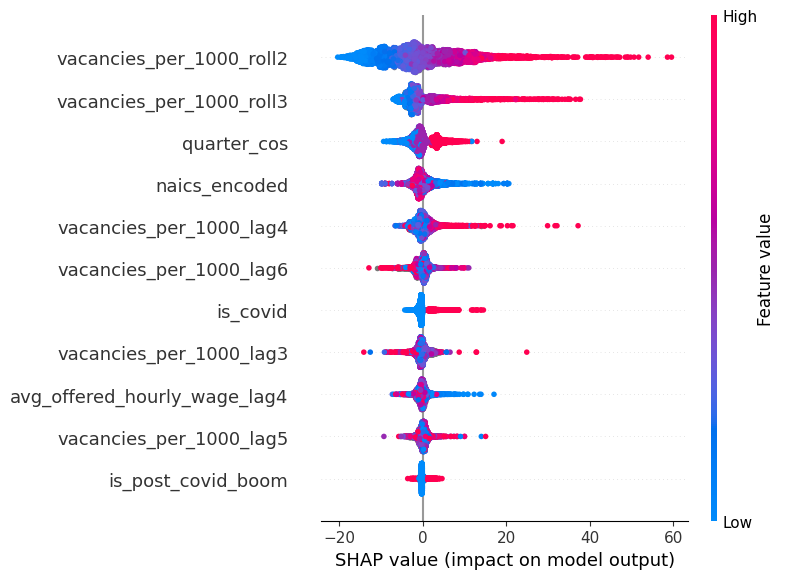

<Figure size 640x480 with 0 Axes>

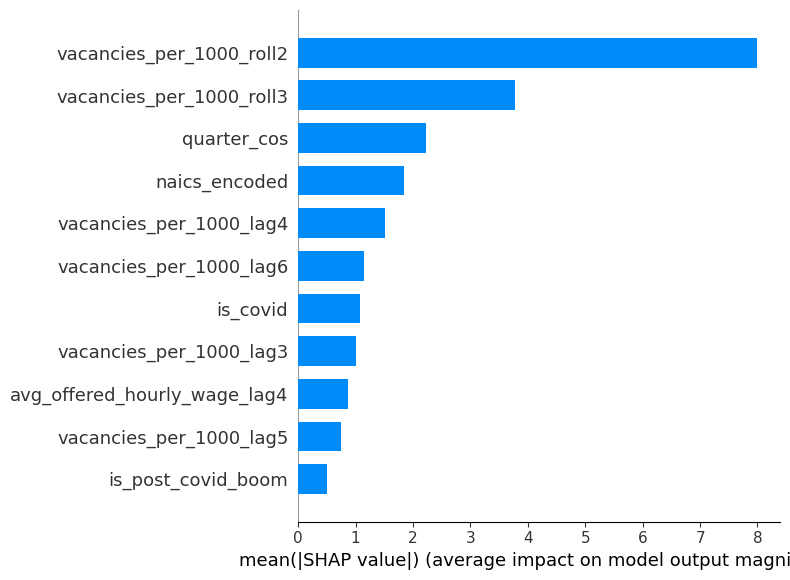

<Figure size 640x480 with 0 Axes>

In [0]:
def build_xgb():
    return xgb.XGBRegressor()

def eval_metrics(y_test, y_pred):
    return {
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
        'mae': mean_absolute_error(y_test, y_pred),
        'mape': np.mean(np.abs((y_test - y_pred) / y_test)) * 100,
        'r2': r2_score(y_test, y_pred)
    }

# Train
model_vacancies = build_xgb()
model_vacancies.fit(quarterly_x_vacancies_train, quarterly_y_vacancies_train)

# Evaluate on held-out test set
y_pred_vacancies = model_vacancies.predict(quarterly_x_vacancies_test)
model_results = eval_metrics(quarterly_y_vacancies_test, y_pred_vacancies)
print(model_results)

# Naive baseline comparison
y_pred_naive_vacancies = df_quarterly_features['vacancies_per_1000_lag1'][test_mask_vacancies & valid_mask_vacancies].reset_index(drop=True)
print(eval_metrics(quarterly_y_vacancies_test, y_pred_naive_vacancies))

# Naive yearly baseline comparison
y_pred_naive_yearly_vacancies = quarterly_x_vacancies_test['vacancies_per_1000_lag4']
print(eval_metrics(quarterly_y_vacancies_test, y_pred_naive_yearly_vacancies))

# SHAP on training data
explainer = shap.TreeExplainer(model_vacancies)
shap_values = explainer.shap_values(quarterly_x_vacancies_train)

plt.figure()
shap.summary_plot(shap_values, quarterly_x_vacancies_train, feature_names=vacancies_feature_cols)
plt.tight_layout()
plt.show()

plt.figure()
shap.summary_plot(shap_values, quarterly_x_vacancies_train, feature_names=vacancies_feature_cols, plot_type='bar')
plt.tight_layout()
plt.show()


##### Ablation and Permutation Testing

In [0]:
def ablation_testing(x_train, y_train, x_test, y_test, model_builder):
    model = model_builder()
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    return np.sqrt(mean_squared_error(y_test, y_pred))

# Baseline RMSE
baseline_rmse_vacancies = ablation_testing(
    quarterly_x_vacancies_train, quarterly_y_vacancies_train,
    quarterly_x_vacancies_test, quarterly_y_vacancies_test,
    build_xgb
)

# Ablation loop
ablation_results_vacancies = []
for feat in vacancies_feature_cols:
    feats_keep = [f for f in vacancies_feature_cols if f != feat]
    
    ablated_rmse_vacancies = ablation_testing(
        quarterly_x_vacancies_train[feats_keep], quarterly_y_vacancies_train,
        quarterly_x_vacancies_test[feats_keep], quarterly_y_vacancies_test,
        build_xgb
    )
    
    diff_vacancies = baseline_rmse_vacancies - ablated_rmse_vacancies  # positive = removing this feature hurt the model
    ablation_results_vacancies.append({'feature': feat, 'rmse_diff': diff_vacancies})

ablation_df_vacancies = pd.DataFrame(ablation_results_vacancies).sort_values('rmse_diff', ascending=False)
print(ablation_df_vacancies)

                         feature  rmse_diff
0        vacancies_per_1000_lag3  -0.136656
6       vacancies_per_1000_roll3  -0.144052
2        vacancies_per_1000_lag5  -0.241662
1        vacancies_per_1000_lag4  -0.272354
10                 naics_encoded  -0.320529
9             is_post_covid_boom  -0.375083
4   avg_offered_hourly_wage_lag4  -0.449607
5       vacancies_per_1000_roll2  -0.469754
3        vacancies_per_1000_lag6  -0.609496
7                    quarter_cos  -0.692566
8                       is_covid  -1.166138


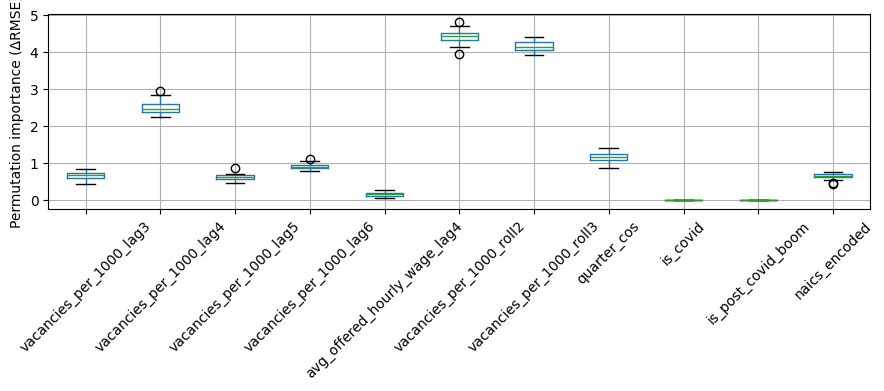

vacancies_per_1000_roll2        4.427389
vacancies_per_1000_roll3        4.161230
vacancies_per_1000_lag4         2.505345
quarter_cos                     1.179961
vacancies_per_1000_lag6         0.917928
vacancies_per_1000_lag3         0.671562
naics_encoded                   0.655709
vacancies_per_1000_lag5         0.631652
avg_offered_hourly_wage_lag4    0.163799
is_covid                        0.000000
is_post_covid_boom              0.000000
dtype: float64


In [0]:
def permutation_on_test(model, x_test, y_test, features, n_repeats=30):
    res = permutation_importance(
        model, x_test, y_test,
        n_repeats=n_repeats,
        random_state=0,
        scoring='neg_root_mean_squared_error'
    )
    return {f: res.importances[i] for i, f in enumerate(features)}

imp_dict_vacancies = permutation_on_test(
    model_vacancies,
    quarterly_x_vacancies_test,
    quarterly_y_vacancies_test,
    vacancies_feature_cols
)

imp_df_vacancies = pd.DataFrame(imp_dict_vacancies)

plt.figure(figsize=(9, 4))
imp_df_vacancies.boxplot(rot=45)
plt.ylabel('Permutation importance (ΔRMSE)')
plt.tight_layout()
plt.show()

print(imp_df_vacancies.mean().sort_values(ascending=False))


#### Average Hourly Wage

{'rmse': np.float64(2.0428730943278564), 'mae': 1.3894723087774592, 'mape': np.float64(4.9265523818347), 'r2': 0.9003651311417148}
{'rmse': np.float64(2.1524370801359454), 'mae': 1.4654886561954625, 'mape': np.float64(5.279440272783349), 'r2': 0.8893912443752212}
{'rmse': np.float64(2.7595855996492915), 'mae': 2.007911576497964, 'mape': np.float64(7.142872734211483), 'r2': 0.8181906072171767}


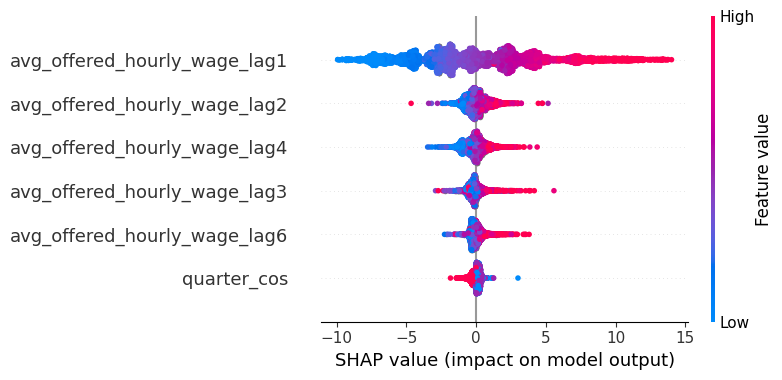

<Figure size 640x480 with 0 Axes>

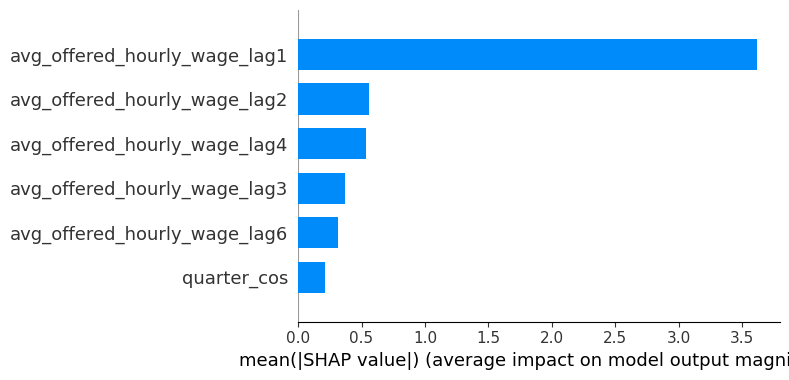

<Figure size 640x480 with 0 Axes>

In [0]:
# Train
model_wage = build_xgb()
model_wage.fit(quarterly_x_wage_train, quarterly_y_wage_train)

# Evaluate on held-out test set
y_pred_wage = model_wage.predict(quarterly_x_wage_test)
model_results = eval_metrics(quarterly_y_wage_test, y_pred_wage)
print(model_results)

# Naive baseline comparison
y_pred_naive_wage = df_quarterly_features['avg_offered_hourly_wage_lag1'][test_mask_wage & valid_mask_wage].reset_index(drop=True)
print(eval_metrics(quarterly_y_wage_test, y_pred_naive_wage))

# Naive yearly baseline comparison
y_pred_naive_yearly_wage = quarterly_x_wage_test['avg_offered_hourly_wage_lag4']
print(eval_metrics(quarterly_y_wage_test, y_pred_naive_yearly_wage))

# SHAP on training data
explainer = shap.TreeExplainer(model_wage)
shap_values = explainer.shap_values(quarterly_x_wage_train)

plt.figure()
shap.summary_plot(shap_values, quarterly_x_wage_train, feature_names=wage_feature_cols)
plt.tight_layout()
plt.show()

plt.figure()
shap.summary_plot(shap_values, quarterly_x_wage_train, feature_names=wage_feature_cols, plot_type='bar')
plt.tight_layout()
plt.show()


##### Ablation and Permutation Testing

In [0]:
# Baseline RMSE
baseline_rmse_wage = ablation_testing(
    quarterly_x_wage_train, quarterly_y_wage_train,
    quarterly_x_wage_test, quarterly_y_wage_test,
    build_xgb
)

# Ablation loop
ablation_results_wage = []
for feat in wage_feature_cols:
    feats_keep = [f for f in wage_feature_cols if f != feat]
    
    ablated_rmse_wage = ablation_testing(
        quarterly_x_wage_train[feats_keep], quarterly_y_wage_train,
        quarterly_x_wage_test[feats_keep], quarterly_y_wage_test,
        build_xgb
    )
    
    diff_wage = baseline_rmse_wage - ablated_rmse_wage  # positive = removing this feature hurt the model
    ablation_results_wage.append({'feature': feat, 'rmse_diff': diff_wage})

ablation_df_wage = pd.DataFrame(ablation_results_wage).sort_values('rmse_diff', ascending=False)
print(ablation_df_wage)

                        feature  rmse_diff
4  avg_offered_hourly_wage_lag6  -0.065328
2  avg_offered_hourly_wage_lag3  -0.068818
5                   quarter_cos  -0.068981
3  avg_offered_hourly_wage_lag4  -0.082334
1  avg_offered_hourly_wage_lag2  -0.117811
0  avg_offered_hourly_wage_lag1  -0.260437


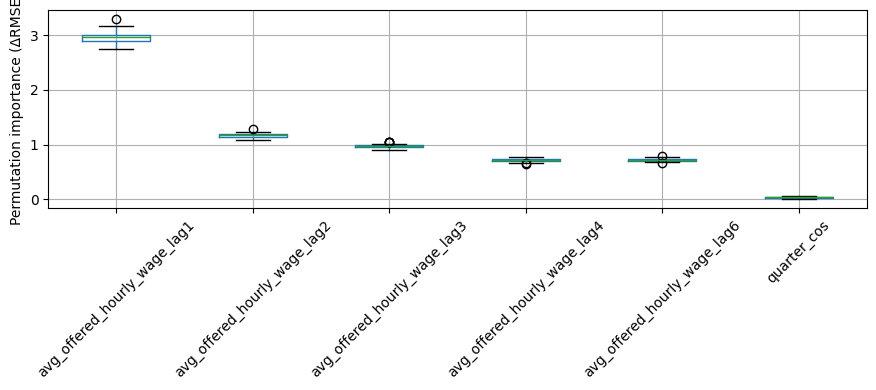

avg_offered_hourly_wage_lag1    2.957196
avg_offered_hourly_wage_lag2    1.168474
avg_offered_hourly_wage_lag3    0.973956
avg_offered_hourly_wage_lag6    0.721334
avg_offered_hourly_wage_lag4    0.717150
quarter_cos                     0.037489
dtype: float64


In [0]:
imp_dict_wage = permutation_on_test(
    model_wage,
    quarterly_x_wage_test,
    quarterly_y_wage_test,
    wage_feature_cols
)

imp_df_wage = pd.DataFrame(imp_dict_wage)

plt.figure(figsize=(9, 4))
imp_df_wage.boxplot(rot=45)
plt.ylabel('Permutation importance (ΔRMSE)')
plt.tight_layout()
plt.show()

print(imp_df_wage.mean().sort_values(ascending=False))

### Hyperparameter Tuning


#### Vacancies per 1000

In [0]:
def objective_vacancies(trial):
    params = {
        'eta':              trial.suggest_float('eta', 0.005, 0.3),
        'max_depth':        trial.suggest_int('max_depth', 3, 6),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 20.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'objective':        'reg:squarederror',
        'seed':             0,
        'verbosity':        0,
    }

    # Split training set into tune-train and tune-val by date
    val_cutoff = pd.Timestamp('2021-01-01')
    tune_train_mask = df_quarterly_features['date_parsed'][train_mask_vacancies & valid_mask_vacancies] < val_cutoff
    
    x_tune_train = quarterly_x_vacancies_train[tune_train_mask.values]
    y_tune_train = quarterly_y_vacancies_train[tune_train_mask.values]
    x_tune_val = quarterly_x_vacancies_train[~tune_train_mask.values]
    y_tune_val = quarterly_y_vacancies_train[~tune_train_mask.values]

    model = xgb.XGBRegressor(**params)
    model.fit(x_tune_train, y_tune_train)
    y_pred = model.predict(x_tune_val)
    return np.sqrt(mean_squared_error(y_tune_val, y_pred))

study_vacancies = optuna.create_study(
    direction='minimize',
    pruner=MedianPruner(n_warmup_steps=5)
)
study_vacancies.optimize(objective_vacancies, n_trials=350)

best_params_vacancies = study_vacancies.best_params

[I 2026-03-31 08:13:46,919] A new study created in memory with name: no-name-dc96a10f-d6d7-4b3e-9fee-654b66238300
[I 2026-03-31 08:13:48,313] Trial 0 finished with value: 14.746237786743627 and parameters: {'eta': 0.2695180059719311, 'max_depth': 6, 'subsample': 0.8945797876095924, 'colsample_bytree': 0.8980869814363489, 'reg_alpha': 0.20749147355815328, 'reg_lambda': 0.008000533603922609, 'n_estimators': 460}. Best is trial 0 with value: 14.746237786743627.
[I 2026-03-31 08:13:48,510] Trial 1 finished with value: 14.142723976457795 and parameters: {'eta': 0.2919800270157861, 'max_depth': 3, 'subsample': 0.7189721262420843, 'colsample_bytree': 0.7284243505083088, 'reg_alpha': 3.770572072329023e-07, 'reg_lambda': 1.2556473730646912e-07, 'n_estimators': 468}. Best is trial 1 with value: 14.142723976457795.
[I 2026-03-31 08:13:48,567] Trial 2 finished with value: 14.018350720893189 and parameters: {'eta': 0.12447426823261316, 'max_depth': 3, 'subsample': 0.687628060776396, 'colsample_bytr

/home/spark-72e6e4ce-ea9b-4879-bf27-60/.ipykernel/3854/command-5266487757070620-3316304734:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


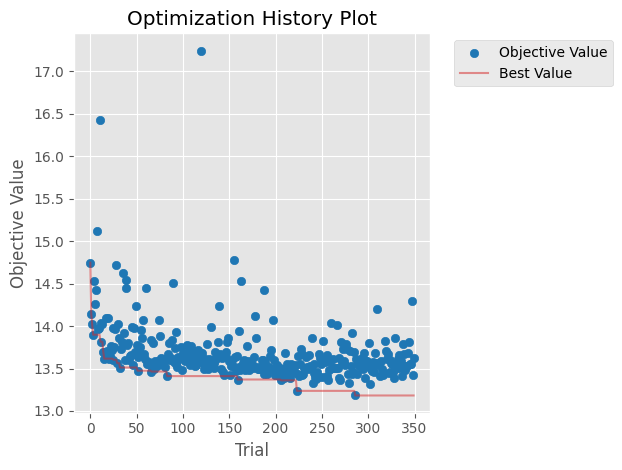

/home/spark-72e6e4ce-ea9b-4879-bf27-60/.ipykernel/3854/command-5266487757070620-3316304734:6: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


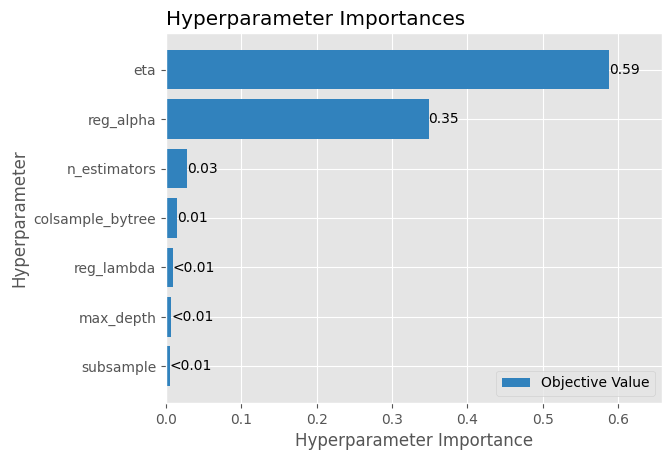

In [0]:
# Plot optimization history
optuna.visualization.matplotlib.plot_optimization_history(study_vacancies)
plt.show()

# Plot parameter importance
optuna.visualization.matplotlib.plot_param_importances(study_vacancies)
plt.show()

#### Average Hourly Wage

In [0]:
def objective_wage(trial):
    params = {
        'eta':              trial.suggest_float('eta', 0.005, 0.3),
        'max_depth':        trial.suggest_int('max_depth', 3, 6),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 20.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'objective':        'reg:squarederror',
        'seed':             0,
        'verbosity':        0,
    }

    # Split training set into tune-train and tune-val by date
    val_cutoff = pd.Timestamp('2021-01-01')
    tune_train_mask = df_quarterly_features['date_parsed'][train_mask_wage & valid_mask_wage] < val_cutoff
    
    x_tune_train = quarterly_x_wage_train[tune_train_mask.values]
    y_tune_train = quarterly_y_wage_train[tune_train_mask.values]
    x_tune_val = quarterly_x_wage_train[~tune_train_mask.values]
    y_tune_val = quarterly_y_wage_train[~tune_train_mask.values]

    model = xgb.XGBRegressor(**params)
    model.fit(x_tune_train, y_tune_train)
    y_pred = model.predict(x_tune_val)
    return np.sqrt(mean_squared_error(y_tune_val, y_pred))

study_wage = optuna.create_study(
    direction='minimize',
    pruner=MedianPruner(n_warmup_steps=5)
)
study_wage.optimize(objective_wage, n_trials=350)

best_params_wage = study_wage.best_params

[I 2026-04-05 08:59:35,879] A new study created in memory with name: no-name-6b2ea20e-efd9-4e67-a5d2-b9a8f5ae0d8e
[I 2026-04-05 08:59:36,004] Trial 0 finished with value: 1.985174160915415 and parameters: {'eta': 0.08485781610409927, 'max_depth': 4, 'subsample': 0.6316217324065536, 'colsample_bytree': 0.8141360568380228, 'reg_alpha': 4.0928805055230276e-05, 'reg_lambda': 0.0029615751815362, 'n_estimators': 251}. Best is trial 0 with value: 1.985174160915415.
[I 2026-04-05 08:59:36,298] Trial 1 finished with value: 2.131364238899161 and parameters: {'eta': 0.16536265783868923, 'max_depth': 6, 'subsample': 0.5389673063786613, 'colsample_bytree': 0.651119445209001, 'reg_alpha': 2.9512835443473015e-08, 'reg_lambda': 0.00017106745387630412, 'n_estimators': 355}. Best is trial 0 with value: 1.985174160915415.
[I 2026-04-05 08:59:36,464] Trial 2 finished with value: 2.104050601912658 and parameters: {'eta': 0.19813873483870537, 'max_depth': 4, 'subsample': 0.7416955038811747, 'colsample_bytre

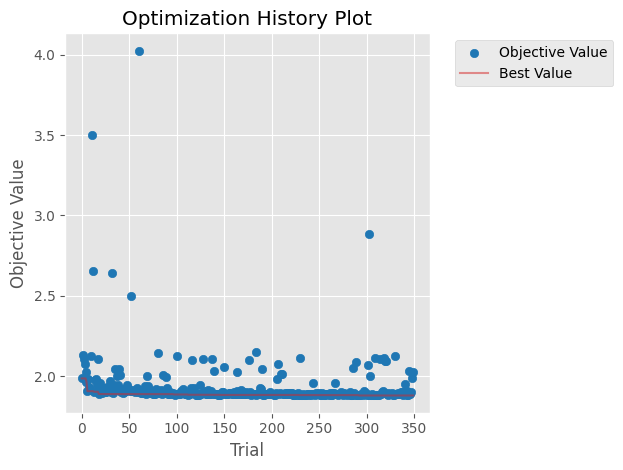

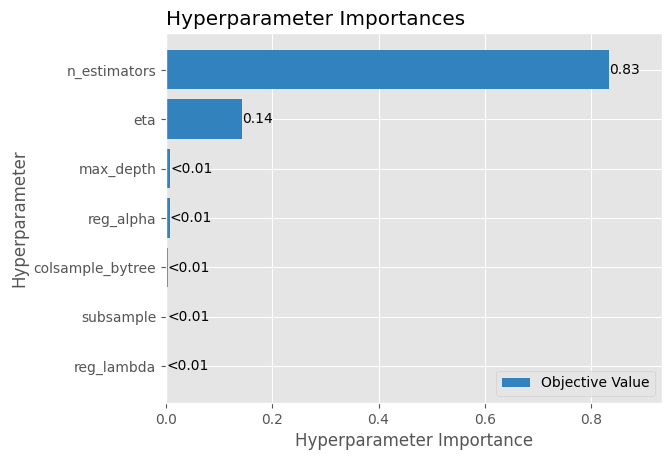

In [0]:
# Plot optimization history
optuna.visualization.matplotlib.plot_optimization_history(study_wage)
plt.show()

# Plot parameter importance
optuna.visualization.matplotlib.plot_param_importances(study_wage)
plt.show()

### Final Model Documentation

In [0]:
# New interpolated quarterly data saved to delta tables
spark.createDataFrame(df_quarterly_features).write.mode("overwrite").saveAsTable("workspace.canada_labour_market.ml_quarterly_features")

In [0]:
df_quarterly_features

,date_parsed,geo,year,naics,job_vacancies,job_vacancy_rate,avg_offered_hourly_wage,payroll_employees,vacancies_per_1000,prev_year_vacancies_per_1000,prev_year_vacancy_rate,prev_year_wage,vacancy_rate_yoy_change_pct,wage_yoy_change_pct,demand_rank,p75_vacancy_rate,p50_vacancy_rate,pct_quarters_above_threshold_2yr,lmia_high_wage_threshold,foreign_accessibility_tier,vacancies_per_1000_lag1,vacancies_per_1000_lag2,vacancies_per_1000_lag3,vacancies_per_1000_lag4,vacancies_per_1000_lag5,vacancies_per_1000_lag6,vacancies_per_1000_roll2,vacancies_per_1000_roll3,vacancies_per_1000_roll6,avg_offered_hourly_wage_lag1,avg_offered_hourly_wage_lag2,avg_offered_hourly_wage_lag3,avg_offered_hourly_wage_lag4,avg_offered_hourly_wage_lag5,avg_offered_hourly_wage_lag6,avg_offered_hourly_wage_roll2,avg_offered_hourly_wage_roll3,avg_offered_hourly_wage_roll6,quarter,quarter_sin,quarter_cos,is_covid,is_post_covid_boom,geo_encoded,naics_encoded
0,2015-01-01,Alberta,2015,Accommodation and food services [72],NaN,NaN,12.55,171575.0,NaN,NaN,NaN,NaN,NaN,NaN,5.0,3.5,2.5,100.0,36.0,Low,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1.0,6.123234e-17,0,0,0,0
1,2015-01-01,Alberta,2015,"Administrative and support, waste management a...",NaN,NaN,20.45,95825.0,NaN,NaN,NaN,NaN,NaN,NaN,5.0,3.5,2.5,66.7,36.0,Low,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1.0,6.123234e-17,0,0,0,1
2,2015-01-01,Alberta,2015,"Agriculture, forestry, fishing and hunting [11]",NaN,NaN,NaN,20415.0,NaN,NaN,NaN,NaN,NaN,NaN,5.0,3.5,2.5,16.7,36.0,Insufficient Data,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1.0,6.123234e-17,0,0,0,2
3,2015-01-01,Alberta,2015,"Arts, entertainment and recreation [71]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,3.5,2.5,33.3,36.0,Insufficient Data,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1.0,6.123234e-17,0,0,0,3
4,2015-01-01,Alberta,2015,Construction [23],NaN,NaN,26.55,206570.0,NaN,NaN,NaN,NaN,NaN,NaN,5.0,3.5,2.5,100.0,36.0,Low,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1.0,6.123234e-17,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11733,2025-07-01,Saskatchewan,2025,Real estate and rental and leasing [53],205.0,3.5,28.15,5600.0,36.607143,NaN,NaN,20.75,NaN,35.66,5.0,3.7,2.8,16.7,33.6,"Above Average Demand, Below Wage Threshold",31.791944,26.976744,27.974506,28.972268,29.970030,10.731707,29.384344,28.914398,26.069533,27.10,24.75,19.95,20.75,23.90,25.20,25.925,23.933333,23.608333,7,-1.0,-4.286264e-16,0,0,10,15
11734,2025-07-01,Saskatchewan,2025,Retail trade [44-45],1680.0,2.6,19.35,62150.0,27.031376,31.454053,3.1,18.30,-14.06,5.74,11.0,3.7,2.8,0.0,33.6,Low,33.742581,28.908697,33.248082,31.454053,42.436466,30.371750,31.325639,31.966453,33.360271,19.10,20.30,19.55,18.30,18.15,18.85,19.700,19.650000,19.041667,7,-1.0,-4.286264e-16,0,0,10,16
11735,2025-07-01,Saskatchewan,2025,"Total, all industries",16025.0,3.1,25.75,500700.0,32.005193,37.799534,3.6,25.30,-15.33,1.78,7.0,3.7,2.8,16.7,33.6,"Above Average Demand, Below Wage Threshold",36.846787,33.024741,33.784917,37.799534,44.665290,41.311218,34.935764,34.552148,37.905415,25.40,25.80,26.10,25.30,24.35,24.15,25.600,25.766667,25.183333,7,-1.0,-4.286264e-16,0,0,10,17
11736,2025-07-01,Saskatchewan,2025,Transportation and warehousing [48-49],555.0,2.7,28.05,20045.0,27.687703,44.705882,4.3,26.65,-38.07,5.25,10.0,3.7,2.8,66.7,33.6,Low,43.202033,52.379753,44.015444,44.705882,64.524695,52.755289,47.790893,46.532410,50.263849,27.05,28.70,25.85,26.65,25.30,25.80,27.875,27.200000,26.558333,7,-1.0,-4.286264e-16,0,0,10,18



#### Vacancies per 1000

In [0]:
# Model
best_params_vacancies = {
        'eta': 0.08954145715868994, # obtained from optuna trial
        'max_depth': 4,
        'subsample': 0.5539515265231724,
        'colsample_bytree': 0.8506922606263637,
        'reg_alpha': 7.567731365052209e-05,
        'reg_lambda': 1.8828372741926294,
        'n_estimators': 427,
        'random_state': 0
 }

def final_quarterly_vacancies_xgb():
        return xgb.XGBRegressor(**best_params_vacancies)


eval_model = final_quarterly_vacancies_xgb()
eval_model.fit(quarterly_x_vacancies_train, quarterly_y_vacancies_train)

y_pred_train_vacancies = eval_model.predict(quarterly_x_vacancies_train)
y_pred_test_vacancies = eval_model.predict(quarterly_x_vacancies_test)
y_pred_naive_vacancies_lag1 = df_quarterly_features[test_mask_vacancies & valid_mask_vacancies]['vacancies_per_1000_lag1'].reset_index(drop=True)
y_pred_naive_vacancies_lag4 = df_quarterly_features[test_mask_vacancies & valid_mask_vacancies]['vacancies_per_1000_lag4'].reset_index(drop=True)

train_rmse_vacancies = np.sqrt(mean_squared_error(quarterly_y_vacancies_train, y_pred_train_vacancies))
test_rmse_vacancies = np.sqrt(mean_squared_error(quarterly_y_vacancies_test, y_pred_test_vacancies))
test_mae_vacancies = mean_absolute_error(quarterly_y_vacancies_test, y_pred_test_vacancies)
test_mape_vacancies = np.mean(np.abs((quarterly_y_vacancies_test - y_pred_test_vacancies) / quarterly_y_vacancies_test)) * 100
test_r2_vacancies = r2_score(quarterly_y_vacancies_test, y_pred_test_vacancies)
naive_rmse_vacancies_lag1 = np.sqrt(mean_squared_error(quarterly_y_vacancies_test, y_pred_naive_vacancies_lag1))
naive_rmse_vacancies_lag4 = np.sqrt(mean_squared_error(quarterly_y_vacancies_test, y_pred_naive_vacancies_lag4))

print(f"Train RMSE Vacancies per 1000: {train_rmse_vacancies:.3f}")
print(f"Test RMSE Vacancies per 1000:  {test_rmse_vacancies:.3f}")
print(f"Test MAE Vacancies per 1000:   {test_mae_vacancies:.3f}")
print(f"Test MAPE Vacancies per 1000:  {test_mape_vacancies:.3f}")
print(f"Test R2 Vacancies per 1000:    {test_r2_vacancies:.3f}")
print(f"Naive lag 1 RMSE Vacancies per 1000: {naive_rmse_vacancies_lag1:.3f}")
print(f"Naive lag 4 RMSE Vacancies per 1000: {naive_rmse_vacancies_lag4:.3f}")

Train RMSE Vacancies per 1000: 6.050
Test RMSE Vacancies per 1000:  7.560
Test MAE Vacancies per 1000:   5.193
Test MAPE Vacancies per 1000:  18.772
Test R2 Vacancies per 1000:    0.731
Naive lag 1 RMSE Vacancies per 1000: 9.778
Naive lag 4 RMSE Vacancies per 1000: 13.594


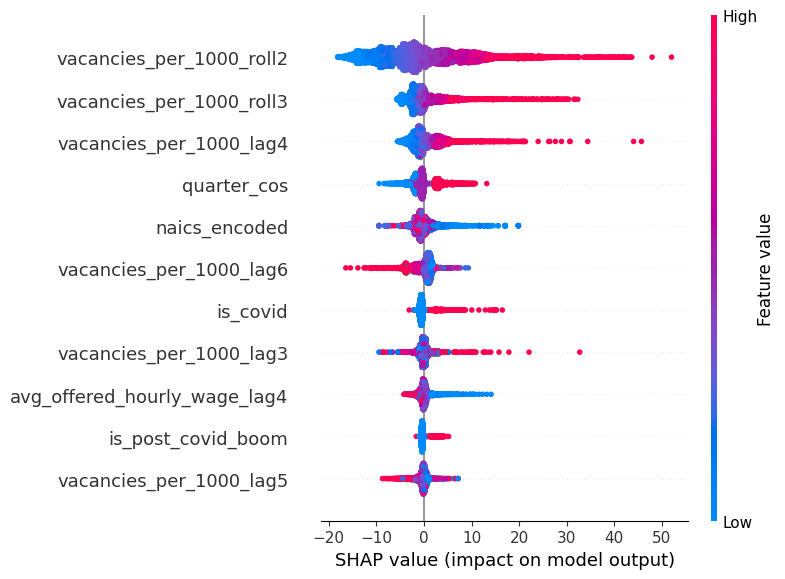

<Figure size 640x480 with 0 Axes>

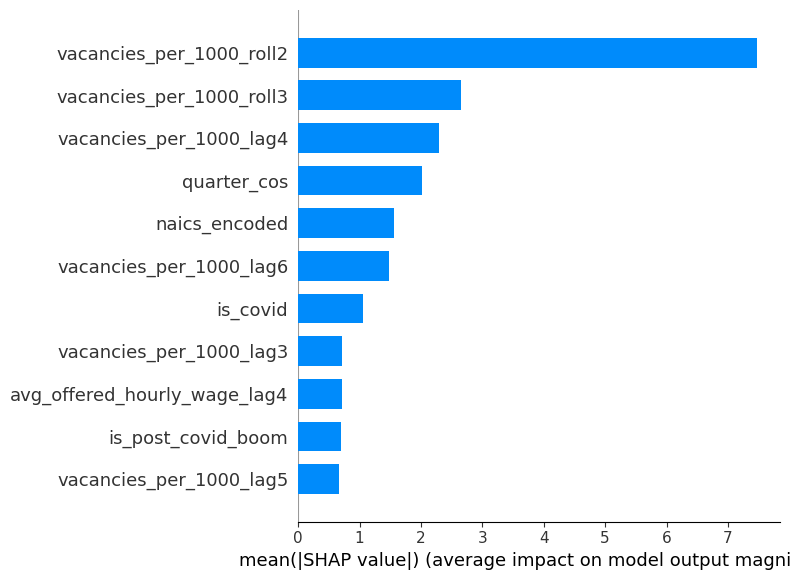

<Figure size 640x480 with 0 Axes>

In [0]:
# Train final model on all data
final_quarterly_vacancies_model = final_quarterly_vacancies_xgb()
final_quarterly_vacancies_model.fit(quarterly_x_vacancies_final, quarterly_y_vacancies_final)

# Compute SHAP values
explainer = shap.TreeExplainer(final_quarterly_vacancies_model)
shap_values = explainer.shap_values(quarterly_x_vacancies_final)

# Summary plot
plt.figure()
shap.summary_plot(shap_values, quarterly_x_vacancies_final, feature_names=vacancies_feature_cols)
plt.tight_layout()
plt.show()

# Bar plot — mean absolute SHAP values
plt.figure()
shap.summary_plot(shap_values, quarterly_x_vacancies_final, feature_names=vacancies_feature_cols, plot_type='bar')
plt.tight_layout()
plt.show()

In [0]:
with mlflow.start_run(run_name="quarterly_vacancies_xgb"):
    # Log hyperparameters
    mlflow.log_params(best_params_vacancies)
    
    # Log metrics
    mlflow.log_metric("train_rmse_vacancies_per_1000", train_rmse_vacancies)
    mlflow.log_metric("test_rmse_vacancies_per_1000", test_rmse_vacancies)
    mlflow.log_metric("test_mae_vacancies_per_1000", test_mae_vacancies)
    mlflow.log_metric("test_mape_vacancies_per_1000", test_mape_vacancies)
    mlflow.log_metric("test_r2_vacancies_per_1000", test_r2_vacancies)
    mlflow.log_metric("naive_lag1_rmse_vacancies_per_1000", naive_rmse_vacancies_lag1)
    mlflow.log_metric("naive_lag4_rmse_vacancies_per_1000", naive_rmse_vacancies_lag4)
    mlflow.log_metric("optuna_val_rmse_vacancies_per_1000", study_vacancies.best_value)

    
    # Log model
    mlflow.xgboost.log_model(
        final_quarterly_vacancies_model, 
        "model",
         input_example=quarterly_x_vacancies_train.iloc[:5]
    )
    
    # Log tags for context
    mlflow.set_tag("train_cutoff", "2023-07-01")
    mlflow.set_tag("val_cutoff", "2021-01-01")
    mlflow.set_tag("target", "vacancies_per_1000")
    mlflow.set_tag("features_dropped", str(remove_cols_vacancies))
    mlflow.set_tag("n_optuna_trials", 350)

    print(f"Run ID: {mlflow.active_run().info.run_id}")
    print("Model logged successfully")

    


/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-72e6e4ce-ea9b-4879-bf27-60218bf2c98e/lib/python3.12/site-packages/xgboost/sklearn.py:1116: UserWarning: [08:43:45] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON 

Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

Run ID: 121a797064d2495ba02cb2ba7c613194
Model logged successfully


In [0]:
client = mlflow.tracking.MlflowClient()
run_id = "121a797064d2495ba02cb2ba7c613194"

client.set_tag(run_id, "overfitting_check", "train RMSE 6.050 vs test RMSE 7.560, mild overfitting detected, likely caused by structural shift in post-COVID normalisation 2023-2024 rather than model configuration issue")
client.set_tag(run_id, "model_improvement_over_naive", "22.7% RMSE reduction vs lag1 naive, 44.4% vs lag4 naive (same quarter as last year)")
client.set_tag(run_id, "optuna_val_rmse_context", "val RMSE at 13.18, as validation period 2021-2022 is post-COVID boom, structurally abnormal, harder to predict from 2015-2020 training data")
client.set_tag(run_id, "vacancy_volatility_note", "vacancies far more volatile than wage, MAPE 18.7% is reasonable given sector-level granularity across multiple provinces")
client.set_tag(run_id, "research_context", "combined with wage forecast to identify sectors with high demand and above LMIA threshold wages, directly informing foreign worker accessibility analysis")
client.set_tag(run_id, "partitioned", "Roughly partitioned 60% for training, 20% for optuna validation, and 20% for testing")


#### Average Hourly Wage

In [0]:
# Model
best_params_wage = {
        'eta': 0.014328208515775934, # obtained from optuna trial
        'max_depth': 3,
        'subsample': 0.528896845567887,
        'colsample_bytree': 0.5829240994697549,
        'reg_alpha': 13.268668727149025,
        'reg_lambda': 0.20524685212400157,
        'n_estimators': 500, # was checked for hitting boundary, but n_estimators did not exceed 500 after 2 additional trials
        'random_state': 0
 }

def final_quarterly_wage_xgb():
        return xgb.XGBRegressor(**best_params_wage)


eval_model = final_quarterly_wage_xgb()
eval_model.fit(quarterly_x_wage_train, quarterly_y_wage_train)

y_pred_train_wage = eval_model.predict(quarterly_x_wage_train)
y_pred_test_wage = eval_model.predict(quarterly_x_wage_test)
y_pred_naive_wage_lag1 = df_quarterly_features[test_mask_wage & valid_mask_wage]['avg_offered_hourly_wage_lag1'].reset_index(drop=True)
y_pred_naive_wage_lag4 = df_quarterly_features[test_mask_wage & valid_mask_wage]['avg_offered_hourly_wage_lag4'].reset_index(drop=True)

train_rmse_wage = np.sqrt(mean_squared_error(quarterly_y_wage_train, y_pred_train_wage))
test_rmse_wage = np.sqrt(mean_squared_error(quarterly_y_wage_test, y_pred_test_wage))
test_mae_wage = mean_absolute_error(quarterly_y_wage_test, y_pred_test_wage)
test_mape_wage = np.mean(np.abs((quarterly_y_wage_test - y_pred_test_wage) / quarterly_y_wage_test)) * 100
test_r2_wage = r2_score(quarterly_y_wage_test, y_pred_test_wage)
naive_rmse_wage_lag1 = np.sqrt(mean_squared_error(quarterly_y_wage_test, y_pred_naive_wage_lag1))
naive_rmse_wage_lag4 = np.sqrt(mean_squared_error(quarterly_y_wage_test, y_pred_naive_wage_lag4))

print(f"Train RMSE Hourly Wage: {train_rmse_wage:.3f}")
print(f"Test RMSE Hourly Wage:  {test_rmse_wage:.3f}")
print(f"Test MAE Hourly Wage:   {test_mae_wage:.3f}")
print(f"Test MAPE Hourly Wage:  {test_mape_wage:.3f}")
print(f"Test R2 Hourly Wage:    {test_r2_wage:.3f}")
print(f"Naive lag 1 RMSE Wage: {naive_rmse_wage_lag1:.3f}")
print(f"Naive lag 4 RMSE Wage: {naive_rmse_wage_lag4:.3f}")

Train RMSE Hourly Wage: 2.090
Test RMSE Hourly Wage:  2.003
Test MAE Hourly Wage:   1.313
Test MAPE Hourly Wage:  4.597
Test R2 Hourly Wage:    0.904
Naive lag 1 RMSE Wage: 2.152
Naive lag 4 RMSE Wage: 2.760


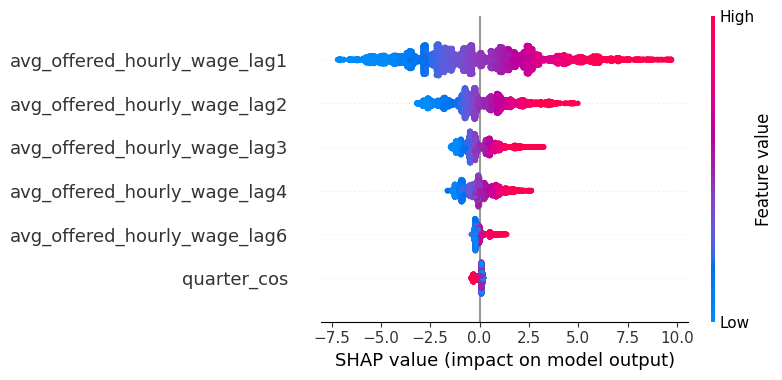

<Figure size 640x480 with 0 Axes>

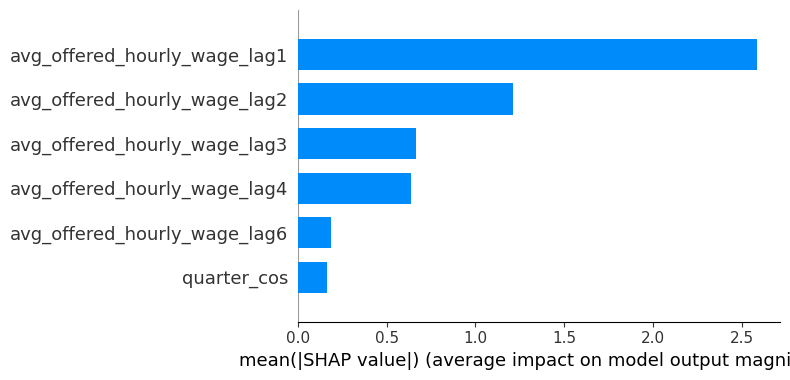

<Figure size 640x480 with 0 Axes>

In [0]:
# Train final model on all data
final_quarterly_wage_model = final_quarterly_wage_xgb()
final_quarterly_wage_model.fit(quarterly_x_wage_final, quarterly_y_wage_final)

# Compute SHAP values
explainer = shap.TreeExplainer(final_quarterly_wage_model)
shap_values = explainer.shap_values(quarterly_x_wage_final)

# Summary plot
plt.figure()
shap.summary_plot(shap_values, quarterly_x_wage_final, feature_names=wage_feature_cols)
plt.tight_layout()
plt.show()

# Bar plot — mean absolute SHAP values
plt.figure()
shap.summary_plot(shap_values, quarterly_x_wage_final, feature_names=wage_feature_cols, plot_type='bar')
plt.tight_layout()
plt.show()

In [0]:
with mlflow.start_run(run_name="quarterly_wage_xgb"):
    # Log hyperparameters
    mlflow.log_params(best_params_wage)
    
    # Log metrics
    mlflow.log_metric("train_rmse_hourly_wage", train_rmse_wage)
    mlflow.log_metric("test_rmse_hourly_wage", test_rmse_wage)
    mlflow.log_metric("test_mae_hourly_wage", test_mae_wage)
    mlflow.log_metric("test_mape_hourly_wage", test_mape_wage)
    mlflow.log_metric("test_r2_hourly_wage", test_r2_wage)
    mlflow.log_metric("naive_lag1_rmse_hourly_wage", naive_rmse_wage_lag1)
    mlflow.log_metric("naive_lag4_rmse_hourly_wage", naive_rmse_wage_lag4)
    mlflow.log_metric("optuna_val_rmse_hourly_wage", study_wage.best_value)
    
    # Log model
    mlflow.xgboost.log_model(
        final_quarterly_wage_model, 
        "quarterly hourly wage model",
         input_example=quarterly_x_wage_train.iloc[:5]
    )
    
    # Log tags for context
    mlflow.set_tag("train_cutoff", "2023-07-01")
    mlflow.set_tag("val_cutoff", "2021-01-01")
    mlflow.set_tag("target", "avg_offered_hourly_wage")
    mlflow.set_tag("features_dropped", str(remove_cols_wage))
    mlflow.set_tag("n_optuna_trials", 350)

    print(f"Run ID: {mlflow.active_run().info.run_id}")
    print("Model logged successfully")

/local_disk0/.ephemeral_nfs/envs/pythonEnv-5af89514-6a8e-451f-8dde-49571e90d46c/lib/python3.12/site-packages/xgboost/sklearn.py:1116: UserWarning: [07:44:49] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)
/local_disk0/.ephemeral_nfs/envs/pythonEnv-5af89514-6a8e-451f-8dde-49571e90d46c/lib/python3.12/site-packages/xgboost/sklearn.py:1125: UserWarning: [07:44:54] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1509: Unknown file format: `xgb`. Using UBJSON (`ubj`) as a guess.
  self.get_booster().load_model(fname)


Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

Run ID: 5e7cbbf256f44cd2a7b37dc2e850c809
Model logged successfully


In [0]:
client = mlflow.tracking.MlflowClient()
run_id = "117e1ac6d4a349b882ab3be2867feb9f" # The run ID will not match the cell above as it was rerun, but this is the original and correct run ID

client.set_tag(run_id, "overfitting_check", "train RMSE 2.090 vs test RMSE 2.003 suggests that the model is not overfitting")
client.set_tag(run_id, "model_improvement_over_naive", "6.9% RMSE reduction vs lag1 naive, 27.4% RMSE reduction vs lag4 naive (same quarter as last year)")
client.set_tag(run_id, "wage_stickiness_note", "Wage is highly autoregressive, model adds 6.9% over naive lag1, useful for LMIA threshold proximity detection")
client.set_tag(run_id, "research_context", "Combined with vacancy forecast to identify sectors accessible for foreign workers above LMIA high wage threshold")
client.set_tag(run_id, "Optuna boundary hit", "The best parameter's n_estimator did hit the boundary, but expanding it and re-running the optuna hyperparameter tuning did not change the results much nor did it even change the n_estimator to go over 500 (repeated twice)")
client.set_tag(run_id, "partitioned", "Roughly partitioned 60% for training, 20% for optuna validation, and 20% for testing")


## Model Forecasting

In [0]:
def create_lags(vals, prefix):
    lag1 = float(vals[-1]) if len(vals) >= 1 else np.nan
    lag2 = float(vals[-2]) if len(vals) >= 2 else np.nan
    lag3 = float(vals[-3]) if len(vals) >= 3 else np.nan
    lag4 = float(vals[-4]) if len(vals) >= 4 else np.nan
    lag5 = float(vals[-5]) if len(vals) >= 5 else np.nan
    lag6 = float(vals[-6]) if len(vals) >= 6 else np.nan

    return {
        f'{prefix}_lag1': lag1,
        f'{prefix}_lag2': lag2,
        f'{prefix}_lag3': lag3,
        f'{prefix}_lag4': lag4,
        f'{prefix}_lag5': lag5,
        f'{prefix}_lag6': lag6,
        f'{prefix}_roll2': float(np.mean([lag1, lag2])),
        f'{prefix}_roll3': float(np.mean([lag1, lag2, lag3])),
        f'{prefix}_roll6': float(np.mean([lag1, lag2, lag3, lag4, lag5, lag6])),
    }


def generate_future_predictions(model, feature_cols, target_col):
    all_predictions = []
    le_geo = LabelEncoder().fit(df_quarterly_features['geo'])
    le_naics = LabelEncoder().fit(df_quarterly_features['naics'])

    for geo in df_quarterly_features['geo'].unique():
        df_geo = df_quarterly_features[df_quarterly_features['geo'] == geo].sort_values('date_parsed').copy()

        for naics in df_geo['naics'].unique():
            df_naics = df_geo[df_geo['naics'] == naics].sort_values('date_parsed').copy()

            for i in range(1, 5):  # 4 quarters ahead
                last_date = df_naics['date_parsed'].max()
                future_date = last_date + pd.DateOffset(months=3)
                
                # Create lags and rolling features
                wage_lags = create_lags(df_naics['avg_offered_hourly_wage'].values, 'avg_offered_hourly_wage')
                vacancy_lags = create_lags(df_naics['vacancies_per_1000'].values, 'vacancies_per_1000')

                # Time features
                quarter = future_date.month
                quarter_sin = np.sin(2 * np.pi * quarter / 4)
                quarter_cos = np.cos(2 * np.pi * quarter / 4)

                new_row = {
                    'date_parsed': future_date,
                    'geo': geo,
                    'naics': naics,
                    **wage_lags,       # unpacks all wage lag/roll keys
                    **vacancy_lags,    # unpacks all vacancy lag/roll keys
                    'quarter': quarter,
                    'quarter_sin': quarter_sin,
                    'quarter_cos': quarter_cos,
                    'is_covid': 0,
                    'is_post_covid_boom': 0,
                    'geo_encoded': float(le_geo.transform([geo])[0]),
                    'naics_encoded': float(le_naics.transform([naics])[0]),
                    target_col: np.nan # placeholder
                }

                X_future = pd.DataFrame([new_row])[feature_cols].astype(float)
                pred = model.predict(X_future)[0]
                new_row[target_col] = pred

                all_predictions.append({
                    'date_parsed': future_date,
                    'geo': geo,
                    'naics': naics,
                    f'predicted_{target_col}': pred,
                    'model': 'xgboost',
                    'forecast_horizon_quarters': i
                })

                # Append predicted row so next iteration can use it as lag
                df_naics = pd.concat([df_naics, pd.DataFrame([new_row])], ignore_index=True)

    return pd.DataFrame(all_predictions)


predictions_vacancies_df = generate_future_predictions(
    model=final_quarterly_vacancies_model,
    feature_cols=vacancies_feature_cols,
    target_col='vacancies_per_1000'
)

predictions_wage_df = generate_future_predictions(
    model=final_quarterly_wage_model,
    feature_cols=wage_feature_cols,
    target_col='avg_offered_hourly_wage'
)

In [0]:
spark_predictions_vacancies = spark.createDataFrame(predictions_vacancies_df)
spark_predictions_vacancies.write.mode("overwrite").saveAsTable("workspace.canada_labour_market.predictions_vacancies")

spark_predictions_wage = spark.createDataFrame(predictions_wage_df)
spark_predictions_wage.write.mode("overwrite").saveAsTable("workspace.canada_labour_market.predictions_wage")

print("Predictions saved to Delta table")

# Verify
spark.table("workspace.canada_labour_market.predictions_vacancies").show()
spark.table("workspace.canada_labour_market.predictions_wage").show()

Predictions saved to Delta table
+-------------------+-------+--------------------+----------------------------+-------+-------------------------+
|        date_parsed|    geo|               naics|predicted_vacancies_per_1000|  model|forecast_horizon_quarters|
+-------------------+-------+--------------------+----------------------------+-------+-------------------------+
|2025-10-01 00:00:00|Alberta|Accommodation and...|                    52.75752|xgboost|                        1|
|2026-01-01 00:00:00|Alberta|Accommodation and...|                   49.529934|xgboost|                        2|
|2026-04-01 00:00:00|Alberta|Accommodation and...|                   62.477074|xgboost|                        3|
|2026-07-01 00:00:00|Alberta|Accommodation and...|                   49.159935|xgboost|                        4|
|2025-10-01 00:00:00|Alberta|Wholesale trade [41]|                   25.971502|xgboost|                        1|
|2026-01-01 00:00:00|Alberta|Wholesale trade [41]|     